# Success Rate by MathML Length (4 Cases)

This notebook is intentionally minimal and focused on one task:
plotting success rate by MathML length for four result files.

- Uses **normalized MathML** section for `from-*` files when available.
- Uses shared bins across all files.
- Uses hardcoded manual bin edges that you can edit directly.


In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULT_SPECS = [
    {
        "case": "from-Nemeth (Braille -> MathML)",
        "path": "results/from-Nemeth-gemini-3-pro-preview-2473exs-200tests.txt",
        "direction": "from",
        "prefer_normalized_section": True,
    },
    {
        "case": "to-Nemeth (MathML -> Braille)",
        "path": "results/to-Nemeth-gemini-3-pro-preview-2473exs-200tests.txt",
        "direction": "to",
        "prefer_normalized_section": False,
    },
    {
        "case": "from-UEB (Braille -> MathML)",
        "path": "results/from-ueb-gemini-3-pro-preview-2352exs-200tests.txt",
        "direction": "from",
        "prefer_normalized_section": True,
    },
    {
        "case": "to-UEB (MathML -> Braille)",
        "path": "results/to-ueb-gemini-3-pro-preview-2352exs-200tests.txt",
        "direction": "to",
        "prefer_normalized_section": False,
    },
]

# Easy-to-change manual bin edges (shared across all files)
# Update this list by hand to adjust binning.
LENGTH_BIN_EDGES = [0, 50, 100, 150, 200, 300, 1000]


In [14]:
def find_line_index(lines, predicate):
    for idx, line in enumerate(lines):
        if predicate(line):
            return idx
    return None


def parse_rows(filepath: str, prefer_normalized_section: bool):
    """Parse one file and return rows from either first or normalized section."""
    with open(filepath, "r", encoding="utf-8") as f:
        lines = [raw_line.strip() for raw_line in f]

    first_match_idx = find_line_index(
        lines,
        lambda s: s.startswith("# Match | Test Input") or s.startswith("Match | Test Input"),
    )
    normalized_idx = find_line_index(
        lines,
        lambda s: s.startswith("# Normalized MathML") or s.startswith("Normalized MathML"),
    )

    if first_match_idx is None:
        return [], None

    if prefer_normalized_section and normalized_idx is not None:
        start_idx = normalized_idx + 1
        section_used = 2
    else:
        start_idx = first_match_idx + 1
        section_used = 1

    # When using section 1 and a normalized marker exists later,
    # stop at that marker to avoid mixing both sections.
    if section_used == 1 and normalized_idx is not None and normalized_idx > start_idx:
        end_idx = normalized_idx
    else:
        end_idx = len(lines)

    rows = []
    for line in lines[start_idx:end_idx]:
        if not line or line.startswith("#"):
            continue
        if line.startswith("✓") or line.startswith("✗"):
            parts = line.split(" | ", 3)
            if len(parts) == 4:
                # Skip malformed pseudo-header rows that sometimes appear as "✗ | Test Input | Expected | ..."
                if parts[1] == "Test Input" and parts[2] == "Expected":
                    continue
                rows.append(
                    {
                        "is_success": parts[0] == "✓",
                        "test_input": parts[1],
                        "expected": parts[2],
                        "computed": parts[3],
                    }
                )

    return rows, section_used


def build_dataframe(specs):
    rows = []

    for spec in specs:
        path = Path(spec["path"])
        selected_rows, section_used = parse_rows(str(path), spec["prefer_normalized_section"])

        if not selected_rows:
            raise ValueError(f"No parseable match rows found in: {path}")

        for result in selected_rows:
            # For Braille -> MathML, MathML is in expected.
            # For MathML -> Braille, MathML is the test input.
            if spec["direction"] == "from":
                mathml = result["expected"]
            else:
                mathml = result["test_input"]

            rows.append(
                {
                    "case": spec["case"],
                    "file": str(path),
                    "section_used": section_used,
                    "is_success": result["is_success"],
                    "mathml": mathml,
                    "mathml_length": len(mathml),
                }
            )

    return pd.DataFrame(rows)


In [15]:
df = build_dataframe(RESULT_SPECS)

case_order = [spec["case"] for spec in RESULT_SPECS]

# Sanity check summary per file/case
summary_overall = (
    df.groupby(["case", "file", "section_used"], as_index=False)
      .agg(
          total=("is_success", "size"),
          success_rate=("is_success", "mean"),
          min_length=("mathml_length", "min"),
          max_length=("mathml_length", "max"),
      )
)
summary_overall["success_rate_pct"] = summary_overall["success_rate"] * 100
display(summary_overall)

# Shared hardcoded bins across all four cases
df["length_bin"] = pd.cut(df["mathml_length"], bins=LENGTH_BIN_EDGES, include_lowest=True)
bin_order = list(df["length_bin"].cat.categories)

summary_by_bin = (
    df.groupby(["case", "length_bin"], observed=True)
      .agg(total=("is_success", "size"), success_rate=("is_success", "mean"))
      .reset_index()
)

# Fill missing case/bin combinations so every line uses same x-axis bins
full_index = pd.MultiIndex.from_product([case_order, bin_order], names=["case", "length_bin"])
summary_by_bin = (
    summary_by_bin
    .set_index(["case", "length_bin"])
    .reindex(full_index)
    .reset_index()
)
summary_by_bin["success_rate_pct"] = summary_by_bin["success_rate"] * 100

bin_sizes = (
    df.groupby("length_bin", observed=False)
      .size()
      .reindex(bin_order, fill_value=0)
      .rename("count_total")
      .reset_index()
)
display(bin_sizes)
display(summary_by_bin)


,case,file,section_used,total,success_rate,min_length,max_length,success_rate_pct
0,from-Nemeth (Braille -> MathML),results/from-Nemeth-gemini-3-pro-preview-2473e...,2,200,0.740,23,924,74.0
1,from-UEB (Braille -> MathML),results/from-ueb-gemini-3-pro-preview-2352exs-...,2,200,0.900,23,927,90.0
2,to-Nemeth (MathML -> Braille),results/to-Nemeth-gemini-3-pro-preview-2473exs...,1,200,0.535,23,927,53.5
3,to-UEB (MathML -> Braille),results/to-ueb-gemini-3-pro-preview-2352exs-20...,1,200,0.690,23,927,69.0


,length_bin,count_total
0,"(-0.001, 50.0]",103
1,"(50.0, 100.0]",225
2,"(100.0, 150.0]",149
3,"(150.0, 200.0]",145
4,"(200.0, 300.0]",97
5,"(300.0, 1000.0]",81


,case,length_bin,total,success_rate,success_rate_pct
0,from-Nemeth (Braille -> MathML),"(-0.001, 50.0]",24,0.875000,87.500000
1,from-Nemeth (Braille -> MathML),"(50.0, 100.0]",59,0.762712,76.271186
2,from-Nemeth (Braille -> MathML),"(100.0, 150.0]",25,0.840000,84.000000
3,from-Nemeth (Braille -> MathML),"(150.0, 200.0]",35,0.885714,88.571429
4,from-Nemeth (Braille -> MathML),"(200.0, 300.0]",26,0.615385,61.538462
5,from-Nemeth (Braille -> MathML),"(300.0, 1000.0]",31,0.451613,45.161290
6,to-Nemeth (MathML -> Braille),"(-0.001, 50.0]",29,0.517241,51.724138
7,to-Nemeth (MathML -> Braille),"(50.0, 100.0]",56,0.589286,58.928571
8,to-Nemeth (MathML -> Braille),"(100.0, 150.0]",36,0.444444,44.444444
9,to-Nemeth (MathML -> Braille),"(150.0, 200.0]",30,0.566667,56.666667


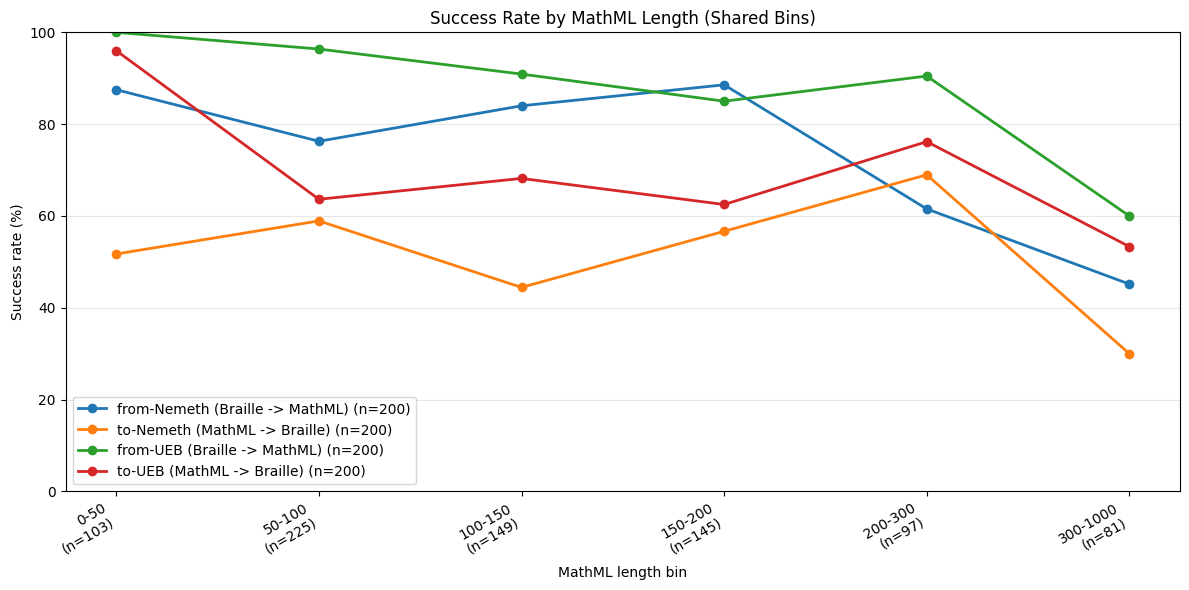

In [16]:
def format_interval(interval) -> str:
    left = int(round(interval.left))
    right = int(round(interval.right))
    return f"{left}-{right}"


x_positions = list(range(len(bin_order)))
bin_count_map = dict(zip(bin_sizes["length_bin"], bin_sizes["count_total"]))
x_labels = [f"{format_interval(interval)}\n(n={bin_count_map.get(interval, 0)})" for interval in bin_order]

fig, ax = plt.subplots(figsize=(12, 6))

for case in case_order:
    case_df = summary_by_bin[summary_by_bin["case"] == case]
    n_case = int(df[df["case"] == case].shape[0])
    ax.plot(
        x_positions,
        case_df["success_rate_pct"],
        marker="o",
        linewidth=2,
        label=f"{case} (n={n_case})",
    )

ax.set_title("Success Rate by MathML Length (Shared Bins)")
ax.set_xlabel("MathML length bin")
ax.set_ylabel("Success rate (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()
